          TRAPEZOIDAL RULE EVALUATION

Problem 1: Limits [1.0, 3.0]
  True Value   : -0.65936355
  Segments (n) : 110
  Approximation: -0.65900718
  Error (Et)   : 0.0540 %

Problem 2: Limits [0.4, 0.989]
  True Value   : 0.97774248
  Segments (n) : 2
  Approximation: 0.97823785
  Error (Et)   : 0.0507 %

Problem 3: Limits [0.0, 4.0]
  True Value   : 34012.44444444
  Segments (n) : 76
  Approximation: 34044.75280232
  Error (Et)   : 0.0950 %

Problem 4: Limits [2.0, 7.0]
  True Value   : 272478081785014255616.00000000
  Segments (n) : 320
  Approximation: 272749663098856472576.00000000
  Error (Et)   : 0.0997 %

Problem 5: Limits [2.0, 7.0]
  True Value   : 38.02682778
  Segments (n) : 6
  Approximation: 38.05215724
  Error (Et)   : 0.0666 %

Generating graphs... Close the graph window to end the program.


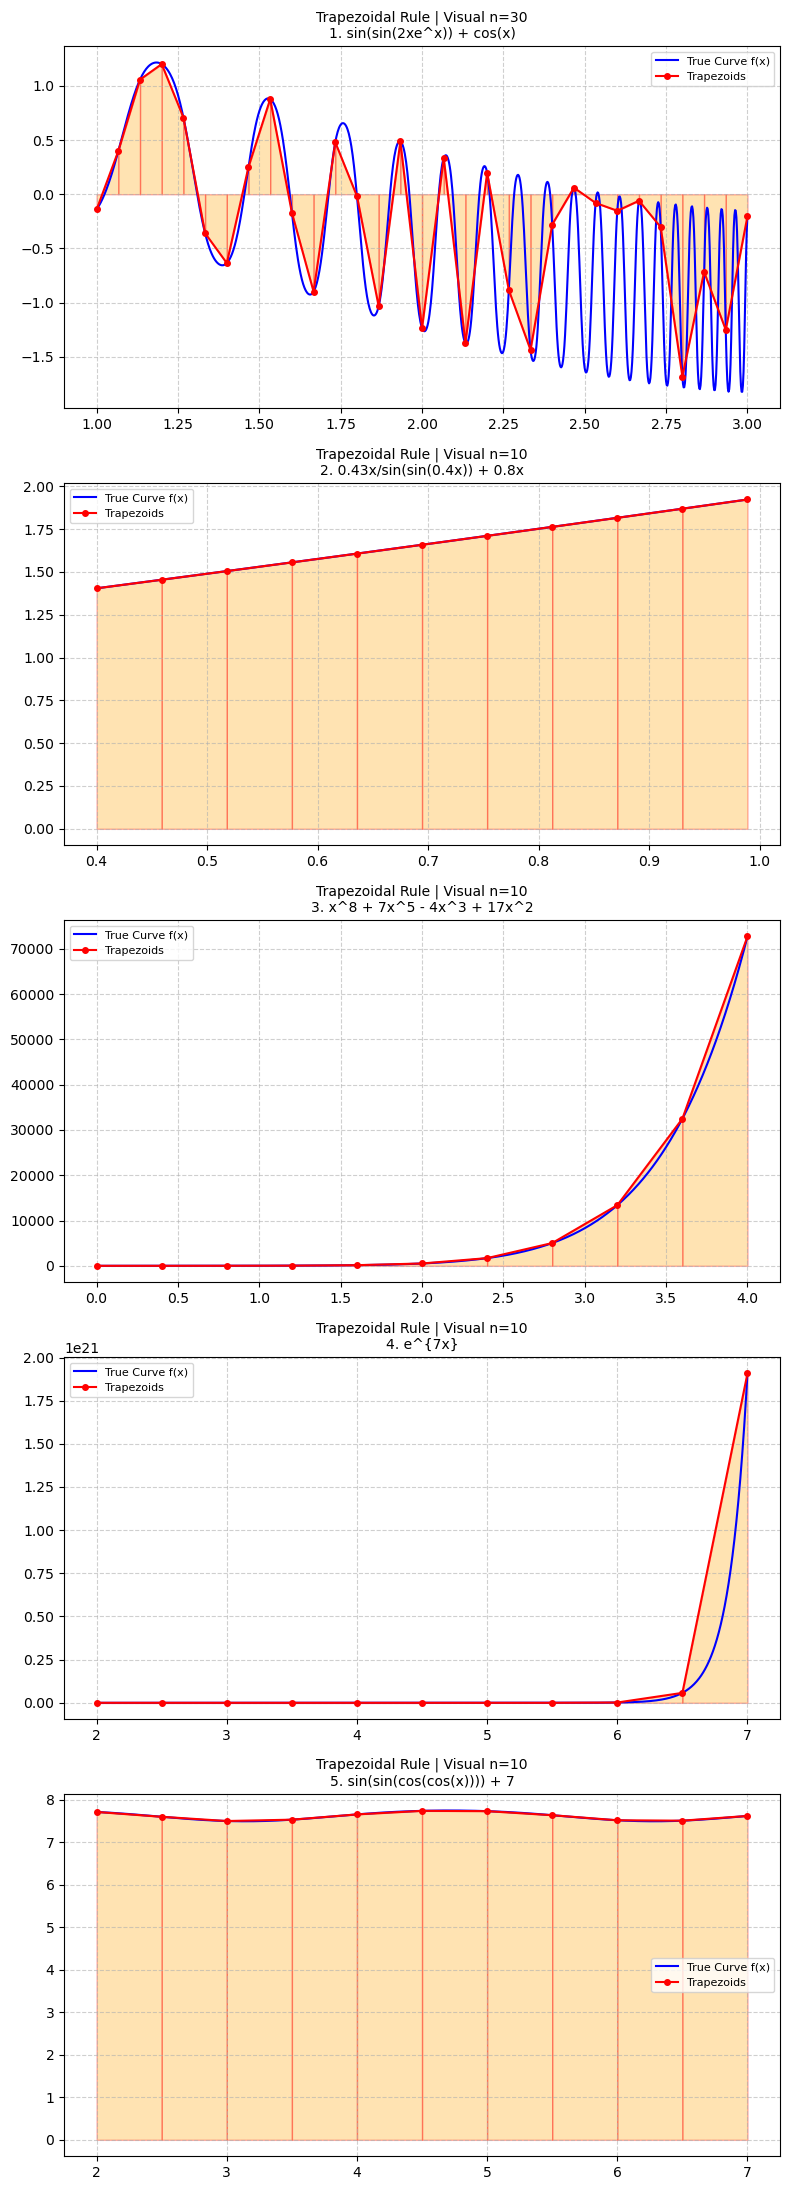

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- 1. Define the Functions ---
def f1(x): return np.sin(np.sin(2 * x * np.exp(x))) + np.cos(x)
def f2(x): return (0.43 * x) / np.sin(np.sin(0.4 * x)) + 0.8 * x
def f3(x): return x**8 + 7*x**5 - 4*x**3 + 17*x**2
def f4(x): return np.exp(7 * x)
def f5(x): return np.sin(np.sin(np.cos(np.cos(x)))) + 7

problems = [
    (f1, 1.0, 3.0, "1. sin(sin(2xe^x)) + cos(x)"),
    (f2, 0.4, 0.989, "2. 0.43x/sin(sin(0.4x)) + 0.8x"),
    (f3, 0.0, 4.0, "3. x^8 + 7x^5 - 4x^3 + 17x^2"),
    (f4, 2.0, 7.0, "4. e^{7x}"),
    (f5, 2.0, 7.0, "5. sin(sin(cos(cos(x)))) + 7")
]

# --- 2. Trapezoidal Method & Error Calculation ---
def trapezoidal_rule(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

def calculate_et(true_val, approx_val):
    if true_val == 0: return 0 
    return abs((true_val - approx_val) / true_val) * 100

# --- 3. Plotting Function ---
def plot_trapezoidal(f, a, b, n, ax, title):
    x_smooth = np.linspace(a, b, 1000)
    y_smooth = f(x_smooth)
    ax.plot(x_smooth, y_smooth, 'b-', label='True Curve f(x)', linewidth=1.5)
    
    x_trap = np.linspace(a, b, n + 1)
    y_trap = f(x_trap)
    
    ax.plot(x_trap, y_trap, 'r-', marker='o', markersize=4, label='Trapezoids', linewidth=1.5)
    for i in range(n):
        ax.fill_between([x_trap[i], x_trap[i+1]], [y_trap[i], y_trap[i+1]], 
                        alpha=0.3, color='orange', edgecolor='red')
    
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.6)

# --- 4. Execution ---
if __name__ == "__main__":
    print("==================================================")
    print("          TRAPEZOIDAL RULE EVALUATION")
    print("==================================================")
    
    target_et = 0.1
    
    # Evaluate and print text output
    for i, (f, a, b, name) in enumerate(problems, start=1):
        true_val, _ = quad(f, a, b, limit=200)
        
        n = 2
        et = 100.0
        approx_val = 0.0
        
        while et > target_et:
            approx_val = trapezoidal_rule(f, a, b, n)
            et = calculate_et(true_val, approx_val)
            if et > target_et:
                n += 2 
                
        print(f"\nProblem {i}: Limits [{a}, {b}]")
        print(f"  True Value   : {true_val:.8f}")
        print(f"  Segments (n) : {n}")
        print(f"  Approximation: {approx_val:.8f}")
        print(f"  Error (Et)   : {et:.4f} %")

    # Generate Graphs
    print("\nGenerating graphs... Close the graph window to end the program.")
    fig, axes = plt.subplots(5, 1, figsize=(8, 22))
    plt.subplots_adjust(hspace=0.4)

    visual_n = 10 

    for i, (f, a, b, name) in enumerate(problems):
        n_plot = 30 if i == 0 else visual_n 
        plot_trapezoidal(f, a, b, n_plot, axes[i], f"Trapezoidal Rule | Visual n={n_plot}\n{name}")

    plt.tight_layout()
    plt.show()

         SIMPSON'S 1/3 RULE EVALUATION

Problem 1: Limits [1.0, 3.0]
  True Value   : -0.65936355
  Segments (n) : 122
  Approximation: -0.65962018
  Error (Et)   : 0.0389 %

Problem 2: Limits [0.4, 0.989]
  True Value   : 0.97774248
  Segments (n) : 2
  Approximation: 0.97774259
  Error (Et)   : 0.0000 %

Problem 3: Limits [0.0, 4.0]
  True Value   : 34012.44444444
  Segments (n) : 12
  Approximation: 34036.11522634
  Error (Et)   : 0.0696 %

Problem 4: Limits [2.0, 7.0]
  True Value   : 272478081785014255616.00000000
  Segments (n) : 54
  Approximation: 272732436898078818304.00000000
  Error (Et)   : 0.0933 %

Problem 5: Limits [2.0, 7.0]
  True Value   : 38.02682778
  Segments (n) : 6
  Approximation: 38.00935329
  Error (Et)   : 0.0460 %

Generating graphs... Close the graph window to end the program.


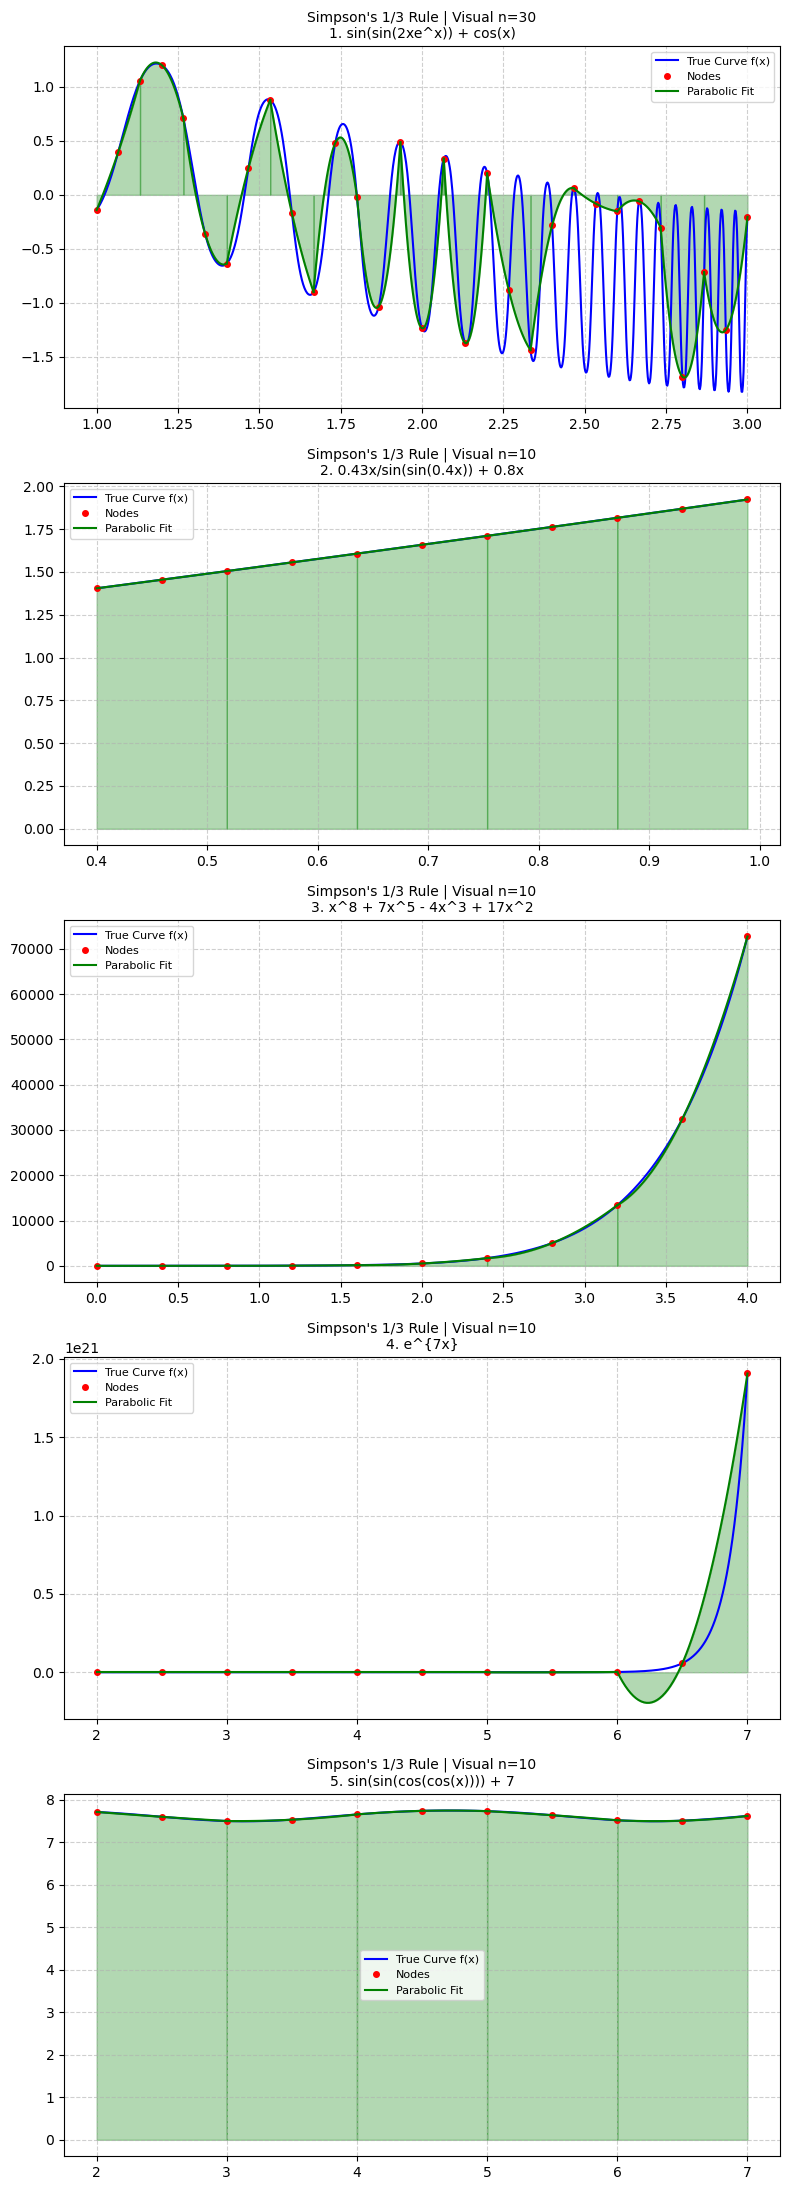

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# --- 1. Define the Functions ---
def f1(x): return np.sin(np.sin(2 * x * np.exp(x))) + np.cos(x)
def f2(x): return (0.43 * x) / np.sin(np.sin(0.4 * x)) + 0.8 * x
def f3(x): return x**8 + 7*x**5 - 4*x**3 + 17*x**2
def f4(x): return np.exp(7 * x)
def f5(x): return np.sin(np.sin(np.cos(np.cos(x)))) + 7

problems = [
    (f1, 1.0, 3.0, "1. sin(sin(2xe^x)) + cos(x)"),
    (f2, 0.4, 0.989, "2. 0.43x/sin(sin(0.4x)) + 0.8x"),
    (f3, 0.0, 4.0, "3. x^8 + 7x^5 - 4x^3 + 17x^2"),
    (f4, 2.0, 7.0, "4. e^{7x}"),
    (f5, 2.0, 7.0, "5. sin(sin(cos(cos(x)))) + 7")
]

# --- 2. Simpson's 1/3 Method & Error Calculation ---
def simpsons_13_rule(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n must be an even integer for Simpson's 1/3 Rule.")
        
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    
    odd_sum = np.sum(y[1:-1:2])
    even_sum = np.sum(y[2:-2:2])
    
    return (h / 3) * (y[0] + 4 * odd_sum + 2 * even_sum + y[-1])

def calculate_et(true_val, approx_val):
    if true_val == 0: return 0 
    return abs((true_val - approx_val) / true_val) * 100

# --- 3. Plotting Function ---
def plot_simpsons(f, a, b, n, ax, title):
    x_smooth = np.linspace(a, b, 1000)
    y_smooth = f(x_smooth)
    ax.plot(x_smooth, y_smooth, 'b-', label='True Curve f(x)', linewidth=1.5)
    
    x_simp = np.linspace(a, b, n + 1)
    y_simp = f(x_simp)
    ax.plot(x_simp, y_simp, 'ro', markersize=4, label='Nodes')
    
    for i in range(0, n, 2):
        x_sub = x_simp[i:i+3]
        y_sub = y_simp[i:i+3]
        
        coeffs = np.polyfit(x_sub, y_sub, 2)
        poly = np.poly1d(coeffs)
        
        x_fit = np.linspace(x_sub[0], x_sub[2], 50)
        y_fit = poly(x_fit)
        
        if i == 0:
            ax.plot(x_fit, y_fit, 'g-', linewidth=1.5, label="Parabolic Fit")
        else:
            ax.plot(x_fit, y_fit, 'g-', linewidth=1.5)
            
        ax.fill_between(x_fit, y_fit, alpha=0.3, color='green', edgecolor='green')
        
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.6)

# --- 4. Execution ---
if __name__ == "__main__":
    print("==================================================")
    print("         SIMPSON'S 1/3 RULE EVALUATION")
    print("==================================================")
    
    target_et = 0.1
    
    # Evaluate and print text output
    for i, (f, a, b, name) in enumerate(problems, start=1):
        true_val, _ = quad(f, a, b, limit=200)
        
        n = 2
        et = 100.0
        approx_val = 0.0
        
        while et > target_et:
            approx_val = simpsons_13_rule(f, a, b, n)
            et = calculate_et(true_val, approx_val)
            if et > target_et:
                n += 2 
                
        print(f"\nProblem {i}: Limits [{a}, {b}]")
        print(f"  True Value   : {true_val:.8f}")
        print(f"  Segments (n) : {n}")
        print(f"  Approximation: {approx_val:.8f}")
        print(f"  Error (Et)   : {et:.4f} %")

    # Generate Graphs
    print("\nGenerating graphs... Close the graph window to end the program.")
    fig, axes = plt.subplots(5, 1, figsize=(8, 22))
    plt.subplots_adjust(hspace=0.4)

    visual_n = 10 

    for i, (f, a, b, name) in enumerate(problems):
        n_plot = 30 if i == 0 else visual_n 
        plot_simpsons(f, a, b, n_plot, axes[i], f"Simpson's 1/3 Rule | Visual n={n_plot}\n{name}")

    plt.tight_layout()
    plt.show()